
# Graph Convolution Model Interpretation

#Model Interpretation for graph Convolutional Model

## Data loading and Preprocessing



In [ ]:
# For Reporducibility
import numpy as np
np.random.seed(42)

In [ ]:
!pip install tensorflow==2.12.0 rdkit==2022.9.4 matplotlib==3.4.3


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.9/37.9 MB 27.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
INFO: pip is looking at multiple versions of jax to determine which version is compatible with other requirements. This could take a while.
INFO: pip is still looking at multiple versions of jax to determine which version is compatible with other requirements. This could take a while.
INFO: This is taking longer than usual. You might need to provide the dependency resolver with stricter constraints to reduce runtime. See https://pip.pypa.io/warnings/backtracking for guidance. If you want to abort this run, press Ctrl + C.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 586.0/586.0 MB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 29.3/29.3 MB 13.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 106.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 62.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [ ]:
!pip install rdkit==2022.9.4 matplotlib==3.4.3

In [ ]:
from google.colab import drive
drive.mount("....")

Mounted at /content/drive


In [ ]:
!pip install deepchem

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 21.5 MB/s eta 0:00:00


In [ ]:
import deepchem as dc
import numpy as np

wandb: WARNING W&B installed but not logged in.  Run `wandb login` or set the WANDB_API_KEY env variable.
wandb: WARNING W&B installed but not logged in.  Run `wandb login` or set the WANDB_API_KEY env variable.


##Primary Dataset

In [ ]:
# Load dataset
import pandas as pd
df=pd.read_excel(".....")
df.head(5)

,Molecule ChEMBL ID,Smiles,IC50,classLabel,IsValidSMILES,Morgan_FP,Molecule,Fingerprint,PCA1,PCA2,tSNE1,tSNE2,MolecularWeight,Frequency,cleanedMol
0,CHEMBL94,CNC(=O)Oc1ccc2c(c1)[C@]1(C)CCN(C)[C@@H]1N2C,28.0,1,True,<rdkit.DataStructs.cDataStructs.ExplicitBitVec...,<rdkit.Chem.rdchem.Mol object at 0x7bcfd8e880b0>,<rdkit.DataStructs.cDataStructs.ExplicitBitVec...,-1.738898,-1.494784,-52.761700,-42.736099,275.352,27,CNC(=O)Oc1ccc2c(c1)[C@]1(C)CCN(C)[C@@H]1N2C
1,CHEMBL207777,Cc1ccccc1NC(=O)Oc1ccc2c(c1)[C@]1(C)CO[C@@H](C1)O2,97.0,1,True,<rdkit.DataStructs.cDataStructs.ExplicitBitVec...,<rdkit.Chem.rdchem.Mol object at 0x7bcfd8e88190>,<rdkit.DataStructs.cDataStructs.ExplicitBitVec...,-1.014164,-1.325272,-63.027809,-53.765778,325.364,1,Cc1ccccc1NC(=O)Oc1ccc2c(c1)[C@]1(C)CO[C@@H](C1)O2
2,CHEMBL205967,CCNC(=O)Oc1ccc2c(c1)[C@]1(C)CO[C@@H](C1)O2,2420.0,0,True,<rdkit.DataStructs.cDataStructs.ExplicitBitVec...,<rdkit.Chem.rdchem.Mol object at 0x7bcfd8e88270>,<rdkit.DataStructs.cDataStructs.ExplicitBitVec...,-1.235565,-1.559108,-61.968063,-54.078575,263.293,1,CCNC(=O)Oc1ccc2c(c1)[C@]1(C)CO[C@@H](C1)O2
3,CHEMBL60119,Cc1ccc2c(N)c3c(nc2c1)CCCC3,100.0,1,True,<rdkit.DataStructs.cDataStructs.ExplicitBitVec...,<rdkit.Chem.rdchem.Mol object at 0x7bcfd8e88430>,<rdkit.DataStructs.cDataStructs.ExplicitBitVec...,2.705664,0.148113,57.758297,-8.911607,212.296,4,Cc1ccc2c(N)c3c(nc2c1)CCCC3
4,CHEMBL294525,CCCCCCCNc1c2c(nc3cc([N+](=O)[O-])ccc13)CCCC2,290.0,1,True,<rdkit.DataStructs.cDataStructs.ExplicitBitVec...,<rdkit.Chem.rdchem.Mol object at 0x7bcfd8e884a0>,<rdkit.DataStructs.cDataStructs.ExplicitBitVec...,3.600017,-0.978574,61.242554,5.783804,341.455,3,CCCCCCCNc1c2c(nc3cc([N+](=O)[O-])ccc13)CCCC2


# Loading the model

In [ ]:
galantamine_df = df[df['Molecule ChEMBL ID'] == 'CHEMBL659']


In [ ]:
galantamine_df

,Molecule ChEMBL ID,Smiles,IC50,classLabel,IsValidSMILES,Morgan_FP,Molecule,Fingerprint,PCA1,PCA2,tSNE1,tSNE2,MolecularWeight,Frequency,cleanedMol
143,CHEMBL659,COc1ccc2c3c1O[C@H]1C[C@@H](O)C=C[C@@]31CCN(C)C2,2090.0,0,True,<rdkit.DataStructs.cDataStructs.ExplicitBitVec...,<rdkit.Chem.rdchem.Mol object at 0x7bcfd8e84660>,<rdkit.DataStructs.cDataStructs.ExplicitBitVec...,-1.604482,-0.005219,-90.199371,0.473097,287.359,25,COc1ccc2c3c1O[C@H]1C[C@@H](O)C=C[C@@]31CCN(C)C2


In [ ]:
pip install rdkit

In [ ]:
import deepchem as dc
import pandas as pd
from rdkit import Chem
from deepchem.feat import ConvMolFeaturizer

# Define the ConvMolFeaturizer
featurizer = ConvMolFeaturizer()

# Featurize the SMILES column
features = featurizer.featurize(df['cleanedMol'].tolist())  # Featurize the molecules in the 'cleanedMol' column

# Extract the target values from the DataFrame
targets = df['classLabel'].tolist()  # Extract the target values from the 'classLabel' column

# Create a DeepChem dataset from the features and targets
dataset = dc.data.NumpyDataset(features, targets)  # Create a DeepChem dataset using the features and targets


In [ ]:
# Split your data into training and test sets
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(dataset.X, dataset.y, test_size=0.15, random_state=42)

In [ ]:
X_train, X_valid, y_train, y_valid = train_test_split(X_train, y_train, test_size=0.15/0.85, random_state=42)

In [ ]:
train_dataset = dc.data.NumpyDataset(X_train, y_train)
valid_dataset = dc.data.NumpyDataset(X_valid, y_valid)
test_dataset = dc.data.NumpyDataset(X_test, y_test)


## Classification Modelling - Graph Convolutional Modelling

### Model Building with best Hyperparameters

In [ ]:
!pip install scikit-learn==1.5.0

In [ ]:
import tensorflow as tf
from tensorflow.keras import backend as K

# Clear the current Keras session
K.clear_session()


In [ ]:
from deepchem.models import GraphConvModel
import joblib

# Train
n_tasks = 1
modela = dc.models.GraphConvModel(n_tasks, batch_size=256, dropout=0.01, mode='classification')
modela.fit(train_dataset, nb_epoch=120)



0.04125346839427948

## Cross species evaluation

### Upload and prep for species datasets
Species datasets: eel (CHEMBL4078), cow (CHEMBL4768), mouse (CHEMBL3199), ray (CHEMBL4780), mosquito (CHEMBL2046266), mouse (CHEMBL3198), and independent  human dataset containing molecules not present on  ChEMBL22  were obtained from Vignaux et al(2023) for validation and specificity inferences.

In [ ]:
df_humanIndependent=pd.read_excel(".....")


### Featurization of smiles on species datasets - Grah Conv

### human Independent

In [ ]:
df_humanIndependent.to_csv(".....", index=False)

In [ ]:

# Define the ConvMolFeaturizer
featurizer = ConvMolFeaturizer()

# Featurize the SMILES column
features = featurizer.featurize(df_humanIndependent['cleanedMol'].tolist())
# Extract the target values from the DataFrame
targets = df_humanIndependent['binary_activities'].tolist()

# Create a DeepChem dataset from the features and targets
dataset_humanIndependent= dc.data.NumpyDataset(features, targets)

### Human Test and Independent dataset evaluation -- graph conv

Confusion Matrix for Human Test dataset:
[[290  74]
 [ 32 216]]
Confusion Matrix for Human Independent dataset:
[[99 39]
 [13 57]]


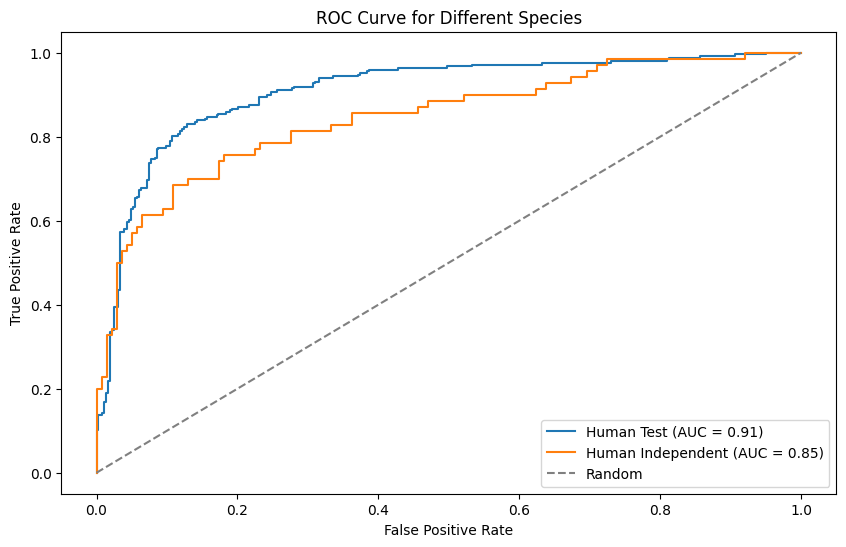

Evaluation for Human Test dataset:
Accuracy: 0.8268
Precision: 0.7448
Recall: 0.8710
F1 Score: 0.8030
MCC: 0.6565
Cohen's Kappa: 0.6501


Evaluation for Human Independent dataset:
Accuracy: 0.7500
Precision: 0.5938
Recall: 0.8143
F1 Score: 0.6867
MCC: 0.5040
Cohen's Kappa: 0.4871




In [ ]:
import deepchem as dc
import tensorflow as tf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, matthews_corrcoef, cohen_kappa_score

datasets = {
    'Human Test': test_dataset,
    'Human Independent': dataset_humanIndependent
}

# Set up the plot
plt.figure(figsize=(10, 6))

# Initialize a dictionary to store evaluation metrics for each dataset
evaluation_metrics = {}

# Evaluate and plot ROC curve for each dataset
for species, data in datasets.items():
    X = data.X
    y_true = data.y.ravel()
    # Make predictions on the test dataset
    y_pred = modela.predict(data).reshape(-1, 2)
    y_pred_positive = y_pred[:, 1]

    # Calculate the ROC curve
    fpr, tpr, _ = roc_curve(y_true, y_pred_positive)

    # Calculate the AUC (Area Under the Curve)
    roc_auc = auc(fpr, tpr)

    # Calculate the confusion matrix
    y_pred_binary = np.argmax(y_pred, axis=1)
    conf_matrix = confusion_matrix(y_true, y_pred_binary)

    # Calculate other evaluation metrics
    accuracy = accuracy_score(y_true, y_pred_binary)
    precision = precision_score(y_true, y_pred_binary)
    recall = recall_score(y_true, y_pred_binary)
    f1 = f1_score(y_true, y_pred_binary)
    mcc = matthews_corrcoef(y_true, y_pred_binary)
    cohen_kappa = cohen_kappa_score(y_true, y_pred_binary)

    # Store the evaluation metrics in the dictionary
    evaluation_metrics[species] = {
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1 Score': f1,
        'MCC': mcc,
        "Cohen's Kappa": cohen_kappa
    }

    # Plot the ROC curve for each species
    plt.plot(fpr, tpr, label=f'{species} (AUC = {roc_auc:.2f})')

    # Display Confusion Matrix
    print(f"Confusion Matrix for {species} dataset:")
    print(conf_matrix)

# Plot settings
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Random')
plt.title('ROC Curve for Different Species')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right')
plt.show()

# Display or analyze the stored evaluation metrics
for species, metrics in evaluation_metrics.items():
    print(f"Evaluation for {species} dataset:")
    for metric_name, value in metrics.items():
        print(f"{metric_name}: {value:.4f}")
    print("\n")

# Create a DataFrame from the evaluation_metrics dictionary
df_metrics = pd.DataFrame(evaluation_metrics).transpose()

# Save the DataFrames to Excel files
df_metrics.to_excel(".....", index_label='Species')


Confusion Matrix for Human Test dataset:
[[290  74]
 [ 32 216]]
Confusion Matrix for Human Independent dataset:
[[99 39]
 [13 57]]


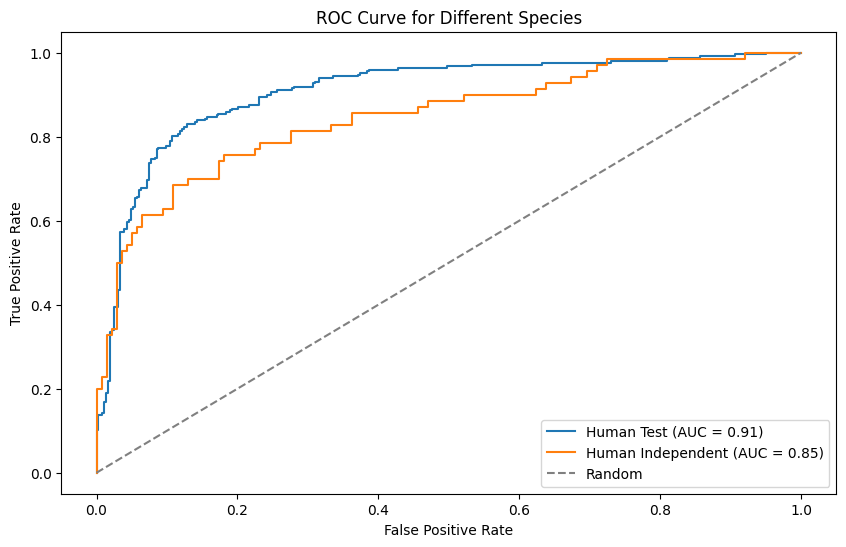

Evaluation for Human Test dataset:
Accuracy: 0.8268
Precision: 0.7448
Recall: 0.8710
F1 Score: 0.8030
MCC: 0.6565
Cohen's Kappa: 0.6501


Evaluation for Human Independent dataset:
Accuracy: 0.7500
Precision: 0.5938
Recall: 0.8143
F1 Score: 0.6867
MCC: 0.5040
Cohen's Kappa: 0.4871




In [ ]:
import deepchem as dc
import tensorflow as tf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, matthews_corrcoef, cohen_kappa_score

datasets = {
    'Human Test': test_dataset,
    'Human Independent': dataset_humanIndependent
}

# Set up the plot
plt.figure(figsize=(10, 6))

# Initialize dictionaries to store evaluation metrics and predictions for each dataset
evaluation_metrics = {}
predictions = {
    'binary': {},
    'class_1': {},
    'class_0': {}
}

# Evaluate and plot ROC curve for each dataset
for species, data in datasets.items():
    X = data.X
    y_true = data.y.ravel()

    # Make predictions on the test dataset
    y_pred = modela.predict(data).reshape(-1, 2)
    y_pred_positive = y_pred[:, 1]
    y_pred_negative = y_pred[:, 0]

    # Store predictions
    predictions['binary'][species] = np.argmax(y_pred, axis=1)
    predictions['class_1'][species] = y_pred_positive
    predictions['class_0'][species] = y_pred_negative

    # Calculate the ROC curve
    fpr, tpr, _ = roc_curve(y_true, y_pred_positive)

    # Calculate the AUC (Area Under the Curve)
    roc_auc = auc(fpr, tpr)

    # Calculate the confusion matrix
    y_pred_binary = np.argmax(y_pred, axis=1)
    conf_matrix = confusion_matrix(y_true, y_pred_binary)

    # Calculate other evaluation metrics
    accuracy = accuracy_score(y_true, y_pred_binary)
    precision = precision_score(y_true, y_pred_binary)
    recall = recall_score(y_true, y_pred_binary)
    f1 = f1_score(y_true, y_pred_binary)
    mcc = matthews_corrcoef(y_true, y_pred_binary)
    cohen_kappa = cohen_kappa_score(y_true, y_pred_binary)

    # Store the evaluation metrics in the dictionary
    evaluation_metrics[species] = {
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1 Score': f1,
        'MCC': mcc,
        "Cohen's Kappa": cohen_kappa
    }

    # Plot the ROC curve for each species
    plt.plot(fpr, tpr, label=f'{species} (AUC = {roc_auc:.2f})')

    # Display Confusion Matrix
    print(f"Confusion Matrix for {species} dataset:")
    print(conf_matrix)

# Plot settings
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Random')
plt.title('ROC Curve for Different Species')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right')
plt.show()

# Display or analyze the stored evaluation metrics
for species, metrics in evaluation_metrics.items():
    print(f"Evaluation for {species} dataset:")
    for metric_name, value in metrics.items():
        print(f"{metric_name}: {value:.4f}")
    print("\n")

# Create separate DataFrames for the evaluation metrics and predictions for each dataset
df_metrics_human_test = pd.DataFrame(evaluation_metrics['Human Test'], index=[0])
df_metrics_human_independent = pd.DataFrame(evaluation_metrics['Human Independent'], index=[0])

df_predictions_human_test = pd.DataFrame({
    'Binary_Prediction': predictions['binary']['Human Test'],
    'Class_1_Prob': predictions['class_1']['Human Test'],
    'Class_0_Prob': predictions['class_0']['Human Test']
})

df_predictions_human_independent = pd.DataFrame({
    'Binary_Prediction': predictions['binary']['Human Independent'],
    'Class_1_Prob': predictions['class_1']['Human Independent'],
    'Class_0_Prob': predictions['class_0']['Human Independent']
})



In [ ]:
data = {'cleanedMol': test_dataset.ids, 'single-class-label': test_dataset.y, 'features': test_dataset.X}

human_test_data = pd.DataFrame(data)

In [ ]:
human_test_data=pd.concat([human_test_data, df_predictions_human_test], axis=1)

In [ ]:
data2 = {'cleanedMol': dataset_humanIndependent.ids, 'single-class-label': dataset_humanIndependent.y, 'features': dataset_humanIndependent.X}

human_Independent_data = pd.DataFrame(data2)

In [ ]:
human_Independent_data=pd.concat([human_Independent_data, df_predictions_human_independent], axis=1)

## Atomic Contribution Visualization

In [ ]:
import pandas as pd
from rdkit import Chem
from rdkit.Chem import PandasTools

# Add the SMILES as a molecule column to the DataFrame
df['Molecule'] = [Chem.MolFromSmiles(smiles) for smiles in df['cleanedMol']]

# Customize the SDF properties (data fields) as needed
df['Name'] = [f'MolID_{index}' for index in df.index]
df['logP50'] = df['IC50']  # Use your own column name for logP50 or logBB
df['classLabel'] = df['classLabel']  # Use your own column name for class label

# Create the SDF file
PandasTools.WriteSDF(df, 'output.sdf', molColName='Molecule', idName='Name', properties=['classLabel', 'logP50'])

print("SDF file created: 'output.sdf'")


SDF file created: 'output.sdf'


In [ ]:
import os
import pandas as pd
import deepchem as dc
import numpy as np
from rdkit import Chem
from rdkit.Chem import AllChem
from rdkit.Chem import Draw, PyMol, rdFMCS
from rdkit.Chem.Draw import IPythonConsole
from rdkit import rdBase
from deepchem import metrics
from IPython.display import Image, display
from rdkit.Chem.Draw import SimilarityMaps
import tensorflow as tf

p= '/content/output.sdf'
# Create RDKit mol objects, since we will need them later.
mols = [m for m in Chem.SDMolSupplier(p) if m is not None ]
lr = dc.data.SDFLoader(tasks=["classLabel"],
                           featurizer=dc.feat.ConvMolFeaturizer(),
                           sanitize=True)
dataset = lr.create_dataset(p, shard_size=2000)


[02:05:47] Warning: ambiguous stereochemistry - zero final chiral volume - at atom 15 ignored
[02:05:47] Warning: ambiguous stereochemistry - zero final chiral volume - at atom 14 ignored
[02:05:48] Warning: ambiguous stereochemistry - zero final chiral volume - at atom 14 ignored
[02:05:48] Warning: ambiguous stereochemistry - zero final chiral volume - at atom 14 ignored
[02:05:48] Warning: ambiguous stereochemistry - overlapping neighbors  - at atom 17 ignored
[02:05:48] Warning: ambiguous stereochemistry - zero final chiral volume - at atom 15 ignored
[02:05:49] Warning: ambiguous stereochemistry - zero final chiral volume - at atom 14 ignored
[02:05:53] Warning: ambiguous stereochemistry - zero final chiral volume - at atom 14 ignored
[02:05:53] Warning: ambiguous stereochemistry - zero final chiral volume - at atom 14 ignored
[02:05:53] Warning: ambiguous stereochemistry - overlapping neighbors  - at atom 17 ignored


In [ ]:
np.random.seed(42)
tf.random.set_seed(42)

In [ ]:
lr = dc.data.SDFLoader(tasks=[],# dont need task (moreover, passing the task can lead to inconsitencies in data shapes)
                        featurizer=dc.feat.ConvMolFeaturizer(per_atom_fragmentation=True),
                        sanitize=True)
fragments = lr.create_dataset(p, shard_size=5000)

[02:05:58] Warning: ambiguous stereochemistry - zero final chiral volume - at atom 15 ignored
[02:05:58] Warning: ambiguous stereochemistry - zero final chiral volume - at atom 14 ignored
[02:05:59] Warning: ambiguous stereochemistry - zero final chiral volume - at atom 14 ignored
[02:05:59] Warning: ambiguous stereochemistry - zero final chiral volume - at atom 14 ignored
[02:05:59] Warning: ambiguous stereochemistry - overlapping neighbors  - at atom 17 ignored
/usr/local/lib/python3.11/dist-packages/deepchem/feat/base_classes.py:322: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  return np.asarray(features)
/usr/local/lib/python3.11/dist-packages/deepchem/data/data_loader.py:917: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a

In [ ]:
tr = dc.trans.FlatteningTransformer(fragments)
fragments = tr.transform(fragments)
print(fragments.X.shape)

In [ ]:
# whole  molecules
prediction = np.squeeze(model.predict(dataset))[:, 1] # probabilitiy of class 1
prediction = pd.DataFrame(prediction, index=dataset.ids, columns=["Molecule"])  # turn to dataframe for convinience

# fragments
prediction_fragments = np.squeeze(model.predict(fragments))[:, 1]
prediction_fragments = pd.DataFrame(prediction_fragments, index=fragments.ids, columns=["Fragment"])

In [ ]:
pred_frags

In [ ]:
df = pd.merge(prediction_fragments, prediction, right_index=True, left_index=True)
df['Contrib'] = df["Molecule"] - df["Fragment"]

In [ ]:
def vis_contribs(mols, df, smi_or_sdf = "sdf"):
    maps = []
    for mol  in mols:
        wt = {}
        if smi_or_sdf == "smi":
            for n,atom in enumerate(Chem.rdmolfiles.CanonicalRankAtoms(mol)):
                wt[atom] = df.loc[mol.GetProp("_Name"),"Contrib"][n]
        if smi_or_sdf == "sdf":
            for n,atom in enumerate(range(mol.GetNumHeavyAtoms())):
                wt[atom] = df.loc[Chem.MolToSmiles(mol),"Contrib"][n]
        maps.append(SimilarityMaps.GetSimilarityMapFromWeights(mol,wt))
    return maps

In [ ]:
np.random.seed(2000)
maps = vis_contribs(np.random.choice(np.array(mols),5), df)

## Atomic contribution visualization for selected screened compounds

The method  and code for atomic contribution visualization is adopted from deep chem tutorial by P-Kelly available at (https://github.com/deepchem/deepchem/blob/master/examples/tutorials/Atomic_Contributions_for_Molecules.ipynb)

In [ ]:
df=pd.read_excel(".....")


In [ ]:
test_compounds= pd.read_excel(".....")

In [ ]:
test_compounds

,Compound,Smiles
0,Demecarium,CN(CCCCCCCCCCN(C)C(=O)Oc1cccc([N+](C)(C)C)c1)C...
1,Donepezil,COc1cc2c(cc1OC)C(=O)[C@H](C[C@H]1CC[N@H+](Cc3c...
2,Dyclonine,CCCCOc1ccc(C(=O)CCN2CCCCC2)cc1
3,Fluindione,C1=CC=C2C(=C1)C(=O)C(C2=O)C3=CC=C(C=C3)F
4,Huperzine A,C/C=C1\[C@H]2C=C(C)C[C@]1(N)c1ccc(=O)[nH]c1C2
5,Pipotiazine,CN(C)S(=O)(=O)C1=CC2=C(C=C1)SC3=CC=CC=C3N2CCCN...
6,7966,C[C@@H]1CCC[C@@H](C)N1S(=O)(=O)c1ccc(Br)cc1\n
7,55025,C[C@H]1CCC[C@@H](C)N1S(=O)(=O)c1ccc(CC#N)cc1\n
8,71569,CCc1ccc(C(=O)C(F)(F)F)cc1\n
9,82311,CCC[C@H]1CCc2nc(NC(=O)c3ccc(C(=O)N(C)C)cc3)sc2...


In [ ]:
from IPython.display import SVG # to use Scalar Vector Graphics (SVG) not bitmaps, for cleaner lines

import rdkit
from rdkit import Chem
from rdkit.Chem import AllChem
from rdkit.Chem import Draw # to draw molecules
from rdkit.Chem.Draw import IPythonConsole # to draw inline in iPython
from rdkit.Chem import rdDepictor  # to generate 2D depictions of molecules
from rdkit.Chem.Draw import rdMolDraw2D # to draw 2D molecules using vectors

from rdkit.Chem.MolStandardize import rdMolStandardize


In [ ]:
def standardize_mol(mol, verbose=False):

    from rdkit.Chem.MolStandardize import rdMolStandardize
    # removeHs, disconnect metal atoms, normalize the molecule, reionize the molecule
    clean_mol = rdMolStandardize.Cleanup(mol)
    if verbose:
        print('Remove Hs, disconnect metal atoms, normalize the molecule, reionize the molecule:')
        #draw_mol_with_SVG(clean_mol)

    # if many fragments, get the "parent" (the actual mol we are interested in)
    parent_clean_mol = rdMolStandardize.FragmentParent(clean_mol)
    if verbose:
        print('Select the "parent" fragment:')
        #draw_mol_with_SVG(parent_clean_mol)

    # try to neutralize molecule
    uncharger = rdMolStandardize.Uncharger() # annoying, but necessary as no convenience method exists
    uncharged_parent_clean_mol = uncharger.uncharge(parent_clean_mol)
    if verbose:
        print('Neutralize the molecule:')
        #draw_mol_with_SVG(uncharged_parent_clean_mol)


    te = rdMolStandardize.TautomerEnumerator() # idem
    taut_uncharged_parent_clean_mol = te.Canonicalize(uncharged_parent_clean_mol)
    if verbose:
        print('Enumerate tautomers:')
        #draw_mol_with_SVG(taut_uncharged_parent_clean_mol)
    assert taut_uncharged_parent_clean_mol != None

    if verbose: print(Chem.MolToSmiles(taut_uncharged_parent_clean_mol))
    return taut_uncharged_parent_clean_mol


def standardize_smiles(smiles, verbose=False):
  """Standardize the SMILES string, select its parent molecule, uncharge it,
    then enumerate all the tautomers."""
  if verbose: print(smiles)
  std_mol = standardize_mol(Chem.MolFromSmiles(smiles), verbose=verbose)
  return Chem.MolToSmiles(std_mol)



In [ ]:
test_compounds['cleanedMol']=test_compounds['Smiles'].apply(standardize_smiles, verbose=True)
test_compounds

CN(CCCCCCCCCCN(C)C(=O)Oc1cccc([N+](C)(C)C)c1)C(=O)Oc1cccc([N+](C)(C)C)c1
Remove Hs, disconnect metal atoms, normalize the molecule, reionize the molecule:
Select the "parent" fragment:
Neutralize the molecule:
Enumerate tautomers:
CN(CCCCCCCCCCN(C)C(=O)Oc1cccc([N+](C)(C)C)c1)C(=O)Oc1cccc([N+](C)(C)C)c1
COc1cc2c(cc1OC)C(=O)[C@H](C[C@H]1CC[N@H+](Cc3ccccc3)CC1)C2
Remove Hs, disconnect metal atoms, normalize the molecule, reionize the molecule:
Select the "parent" fragment:
Neutralize the molecule:
Enumerate tautomers:
COc1cc2c(cc1OC)C(=O)C(CC1CCN(Cc3ccccc3)CC1)C2
CCCCOc1ccc(C(=O)CCN2CCCCC2)cc1
Remove Hs, disconnect metal atoms, normalize the molecule, reionize the molecule:
Select the "parent" fragment:
Neutralize the molecule:
Enumerate tautomers:
CCCCOc1ccc(C(=O)CCN2CCCCC2)cc1
C1=CC=C2C(=C1)C(=O)C(C2=O)C3=CC=C(C=C3)F
Remove Hs, disconnect metal atoms, normalize the molecule, reionize the molecule:
Select the "parent" fragment:
Neutralize the molecule:
Enumerate tautomers:
O=C1c2ccccc2C(

,Compound,Smiles,cleanedMol
0,Demecarium,CN(CCCCCCCCCCN(C)C(=O)Oc1cccc([N+](C)(C)C)c1)C...,CN(CCCCCCCCCCN(C)C(=O)Oc1cccc([N+](C)(C)C)c1)C...
1,Donepezil,COc1cc2c(cc1OC)C(=O)[C@H](C[C@H]1CC[N@H+](Cc3c...,COc1cc2c(cc1OC)C(=O)C(CC1CCN(Cc3ccccc3)CC1)C2
2,Dyclonine,CCCCOc1ccc(C(=O)CCN2CCCCC2)cc1,CCCCOc1ccc(C(=O)CCN2CCCCC2)cc1
3,Fluindione,C1=CC=C2C(=C1)C(=O)C(C2=O)C3=CC=C(C=C3)F,O=C1c2ccccc2C(=O)C1c1ccc(F)cc1
4,Huperzine A,C/C=C1\[C@H]2C=C(C)C[C@]1(N)c1ccc(=O)[nH]c1C2,C/C=C1\[C@H]2C=C(C)C[C@]1(N)c1ccc(=O)[nH]c1C2
5,Pipotiazine,CN(C)S(=O)(=O)C1=CC2=C(C=C1)SC3=CC=CC=C3N2CCCN...,CN(C)S(=O)(=O)c1ccc2c(c1)N(CCCN1CCC(CCO)CC1)c1...
6,7966,C[C@@H]1CCC[C@@H](C)N1S(=O)(=O)c1ccc(Br)cc1\n,C[C@@H]1CCC[C@@H](C)N1S(=O)(=O)c1ccc(Br)cc1
7,55025,C[C@H]1CCC[C@@H](C)N1S(=O)(=O)c1ccc(CC#N)cc1\n,C[C@@H]1CCC[C@H](C)N1S(=O)(=O)c1ccc(CC#N)cc1
8,71569,CCc1ccc(C(=O)C(F)(F)F)cc1\n,CCc1ccc(C(=O)C(F)(F)F)cc1
9,82311,CCC[C@H]1CCc2nc(NC(=O)c3ccc(C(=O)N(C)C)cc3)sc2...,CCC[C@H]1CCc2nc(NC(=O)c3ccc(C(=O)N(C)C)cc3)sc2C1


In [ ]:
test_compounds

,Compound,Smiles,cleanedMol
0,Demecarium,CN(CCCCCCCCCCN(C)C(=O)Oc1cccc([N+](C)(C)C)c1)C...,CN(CCCCCCCCCCN(C)C(=O)Oc1cccc([N+](C)(C)C)c1)C...
1,Donepezil,COc1cc2c(cc1OC)C(=O)[C@H](C[C@H]1CC[N@H+](Cc3c...,COc1cc2c(cc1OC)C(=O)C(CC1CCN(Cc3ccccc3)CC1)C2
2,Dyclonine,CCCCOc1ccc(C(=O)CCN2CCCCC2)cc1,CCCCOc1ccc(C(=O)CCN2CCCCC2)cc1
3,Fluindione,C1=CC=C2C(=C1)C(=O)C(C2=O)C3=CC=C(C=C3)F,O=C1c2ccccc2C(=O)C1c1ccc(F)cc1
4,Huperzine A,C/C=C1\[C@H]2C=C(C)C[C@]1(N)c1ccc(=O)[nH]c1C2,C/C=C1\[C@H]2C=C(C)C[C@]1(N)c1ccc(=O)[nH]c1C2
5,Pipotiazine,CN(C)S(=O)(=O)C1=CC2=C(C=C1)SC3=CC=CC=C3N2CCCN...,CN(C)S(=O)(=O)c1ccc2c(c1)N(CCCN1CCC(CCO)CC1)c1...
6,7966,C[C@@H]1CCC[C@@H](C)N1S(=O)(=O)c1ccc(Br)cc1\n,C[C@@H]1CCC[C@@H](C)N1S(=O)(=O)c1ccc(Br)cc1
7,55025,C[C@H]1CCC[C@@H](C)N1S(=O)(=O)c1ccc(CC#N)cc1\n,C[C@@H]1CCC[C@H](C)N1S(=O)(=O)c1ccc(CC#N)cc1
8,71569,CCc1ccc(C(=O)C(F)(F)F)cc1\n,CCc1ccc(C(=O)C(F)(F)F)cc1
9,82311,CCC[C@H]1CCc2nc(NC(=O)c3ccc(C(=O)N(C)C)cc3)sc2...,CCC[C@H]1CCc2nc(NC(=O)c3ccc(C(=O)N(C)C)cc3)sc2C1


In [ ]:
import pandas as pd
from rdkit import Chem
from rdkit.Chem import PandasTools

test_compounds['Molecule'] = [Chem.MolFromSmiles(smiles) for smiles in test_compounds['cleanedMol']]

test_compounds['Name'] = [f'MolID_{index}' for index in test_compounds.index]

PandasTools.WriteSDF(test_compounds, 'output2.sdf', molColName='Molecule', idName='Name', properties=[])

print("SDF file created: 'output2.sdf'")


SDF file created: 'output2.sdf'


In [ ]:
import os
import pandas as pd
import deepchem as dc
import numpy as np
from rdkit import Chem
from rdkit.Chem import AllChem
from rdkit.Chem import Draw, PyMol, rdFMCS
from rdkit.Chem.Draw import IPythonConsole
from rdkit import rdBase
from deepchem import metrics
from IPython.display import Image, display
from rdkit.Chem.Draw import SimilarityMaps
import tensorflow as tf

path2= '/content/output2.sdf'
mols = [m for m in Chem.SDMolSupplier(path2) if m is not None ]
loader2 = dc.data.SDFLoader(tasks=[],
                           featurizer=dc.feat.ConvMolFeaturizer(),
                           sanitize=True)
datasets2 = loader2.create_dataset(path2, shard_size=2000)


In [ ]:
loader3 = dc.data.SDFLoader(tasks=[],
                        featurizer=dc.feat.ConvMolFeaturizer(per_atom_fragmentation=True),
                        sanitize=True)
frag_dataset2 = loader3.create_dataset(path2, shard_size=5000)

/usr/local/lib/python3.11/dist-packages/deepchem/feat/base_classes.py:322: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  return np.asarray(features)
/usr/local/lib/python3.11/dist-packages/deepchem/data/data_loader.py:917: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  return np.array(features), valid_inds


In [ ]:
frag_dataset2

<DiskDataset X.shape: (22,), y.shape: (), w.shape: (), ids: ['CN(CCCCCCCCCCN(C)C(=O)Oc1cccc([N+](C)(C)C)c1)C(=O)Oc1cccc([N+](C)(C)C)c1'
 'COc1cc2c(cc1OC)C(=O)C(CC1CCN(Cc3ccccc3)CC1)C2'
 'CCCCOc1ccc(C(=O)CCN2CCCCC2)cc1' ... 'Cc1ccc2c(c1)C(=O)C(C)C[C@@H]2O'
 'Cc1ccc2c(c1)[C@H](O)[C@@H](C)CC2=O'
 'Cc1cc(=N)c2ccccc2n1CCCCCCCCCCn1c(C)cc(=N)c2ccccc21'], task_names: []>

In [ ]:
tr = dc.trans.FlatteningTransformer(frag_dataset2)
frag_dataset2 = tr.transform(frag_dataset2)
print(frag_dataset2.X.shape)

(506,)


In [ ]:
# whole  molecules
pred = np.squeeze(modela.predict(datasets2))[:, 1] # probabilitiy of class 1
pred = pd.DataFrame(pred, index=datasets2.ids, columns=["Molecule"])  # turn to dataframe for convinience

# fragments
pred_frags2 = np.squeeze(modela.predict(frag_dataset2))[:, 1]
pred_frags2 = pd.DataFrame(pred_frags2, index=frag_dataset2.ids, columns=["Fragment"])

In [ ]:
pred_frags2

,Fragment
CN(CCCCCCCCCCN(C)C(=O)Oc1cccc([N+](C)(C)C)c1)C(=O)Oc1cccc([N+](C)(C)C)c1,0.784982
CN(CCCCCCCCCCN(C)C(=O)Oc1cccc([N+](C)(C)C)c1)C(=O)Oc1cccc([N+](C)(C)C)c1,0.118464
CN(CCCCCCCCCCN(C)C(=O)Oc1cccc([N+](C)(C)C)c1)C(=O)Oc1cccc([N+](C)(C)C)c1,0.794529
CN(CCCCCCCCCCN(C)C(=O)Oc1cccc([N+](C)(C)C)c1)C(=O)Oc1cccc([N+](C)(C)C)c1,0.284772
CN(CCCCCCCCCCN(C)C(=O)Oc1cccc([N+](C)(C)C)c1)C(=O)Oc1cccc([N+](C)(C)C)c1,0.551902
...,...
Cc1cc(=N)c2ccccc2n1CCCCCCCCCCn1c(C)cc(=N)c2ccccc21,0.976287
Cc1cc(=N)c2ccccc2n1CCCCCCCCCCn1c(C)cc(=N)c2ccccc21,0.988092
Cc1cc(=N)c2ccccc2n1CCCCCCCCCCn1c(C)cc(=N)c2ccccc21,0.996736
Cc1cc(=N)c2ccccc2n1CCCCCCCCCCn1c(C)cc(=N)c2ccccc21,0.879756


In [ ]:
# merge 2 dataframes by molecule names
df2 = pd.merge(pred_frags2, pred, right_index=True, left_index=True)
# find contribs
df2['Contrib'] = df2["Molecule"] - df2["Fragment"]

In [ ]:
df2

,Fragment,Molecule,Contrib
CN(CCCCCCCCCCN(C)C(=O)Oc1cccc([N+](C)(C)C)c1)C(=O)Oc1cccc([N+](C)(C)C)c1,0.784982,0.657076,-0.127906
CN(CCCCCCCCCCN(C)C(=O)Oc1cccc([N+](C)(C)C)c1)C(=O)Oc1cccc([N+](C)(C)C)c1,0.118464,0.657076,0.538612
CN(CCCCCCCCCCN(C)C(=O)Oc1cccc([N+](C)(C)C)c1)C(=O)Oc1cccc([N+](C)(C)C)c1,0.794529,0.657076,-0.137453
CN(CCCCCCCCCCN(C)C(=O)Oc1cccc([N+](C)(C)C)c1)C(=O)Oc1cccc([N+](C)(C)C)c1,0.284772,0.657076,0.372304
CN(CCCCCCCCCCN(C)C(=O)Oc1cccc([N+](C)(C)C)c1)C(=O)Oc1cccc([N+](C)(C)C)c1,0.551902,0.657076,0.105174
...,...,...,...
Cc1cc(=N)c2ccccc2n1CCCCCCCCCCn1c(C)cc(=N)c2ccccc21,0.976287,0.988827,0.012540
Cc1cc(=N)c2ccccc2n1CCCCCCCCCCn1c(C)cc(=N)c2ccccc21,0.988092,0.988827,0.000735
Cc1cc(=N)c2ccccc2n1CCCCCCCCCCn1c(C)cc(=N)c2ccccc21,0.996736,0.988827,-0.007909
Cc1cc(=N)c2ccccc2n1CCCCCCCCCCn1c(C)cc(=N)c2ccccc21,0.879756,0.988827,0.109071


/usr/local/lib/python3.11/dist-packages/rdkit/Chem/Draw/mplCanvas.py:24: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`).
  self._figure = figure(figsize=figsize)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: MatplotlibDeprecationWarning: savefig() got unexpected keyword argument "orientation" which is no longer supported as of 3.3 and will become an error two minor releases later
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: MatplotlibDeprecationWarning: savefig() got unexpected keyword argument "facecolor" which is no longer supported as of 3.3 and will become an error two minor releases later
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/I

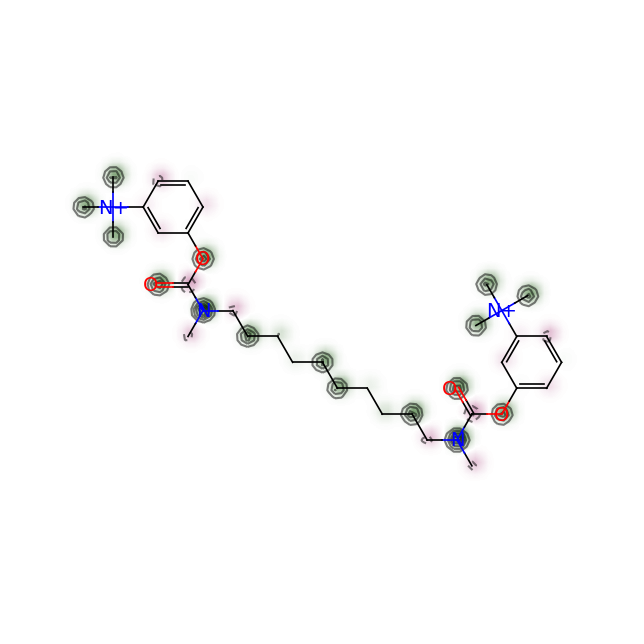

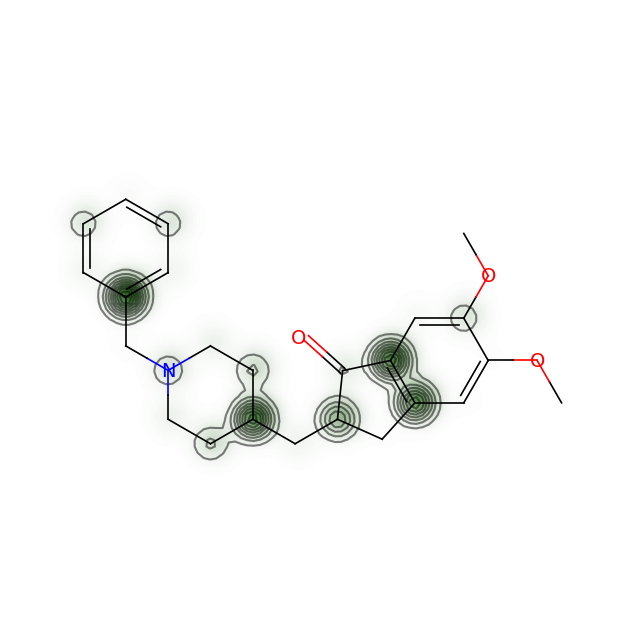

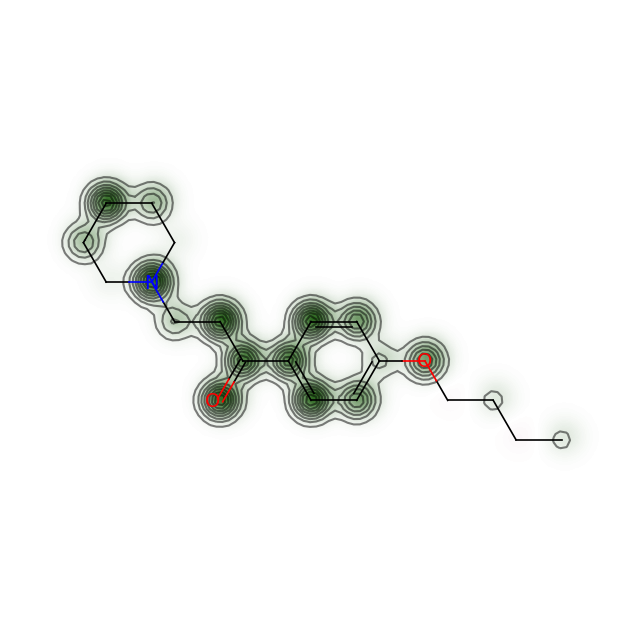

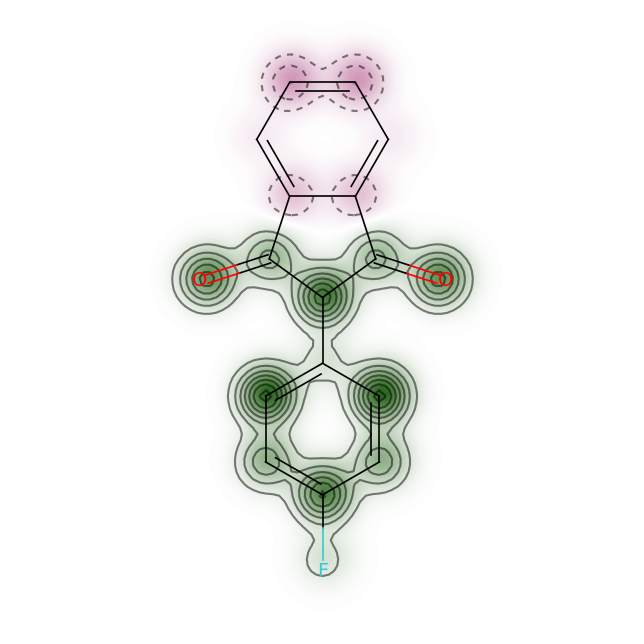

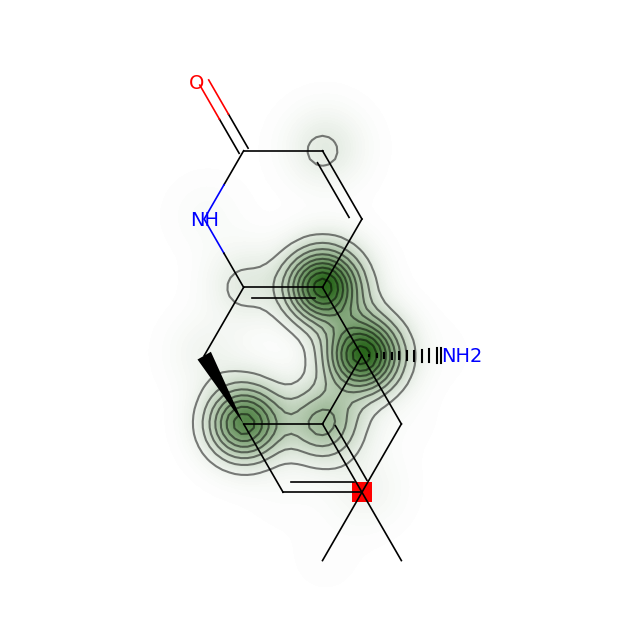

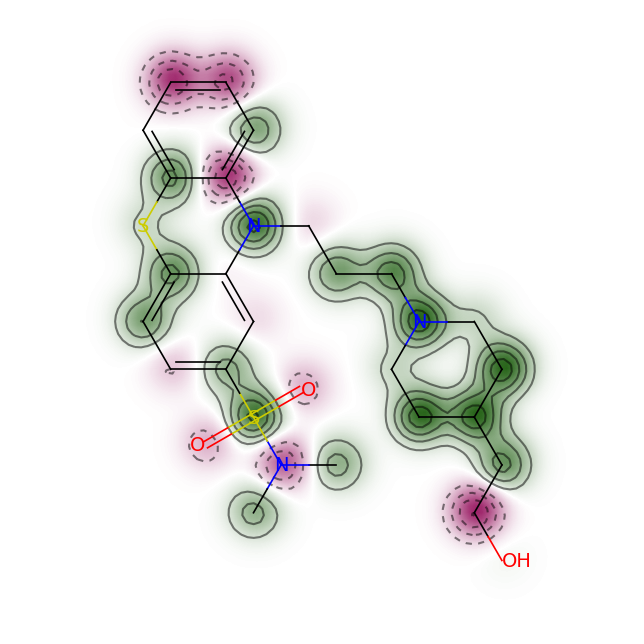

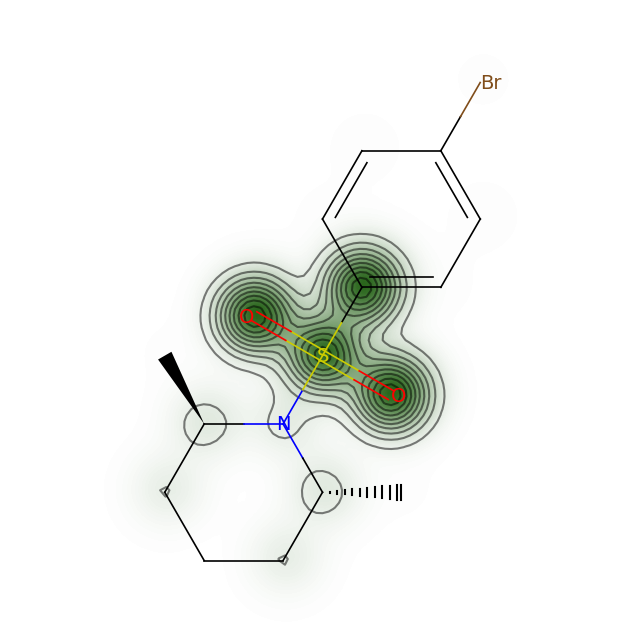

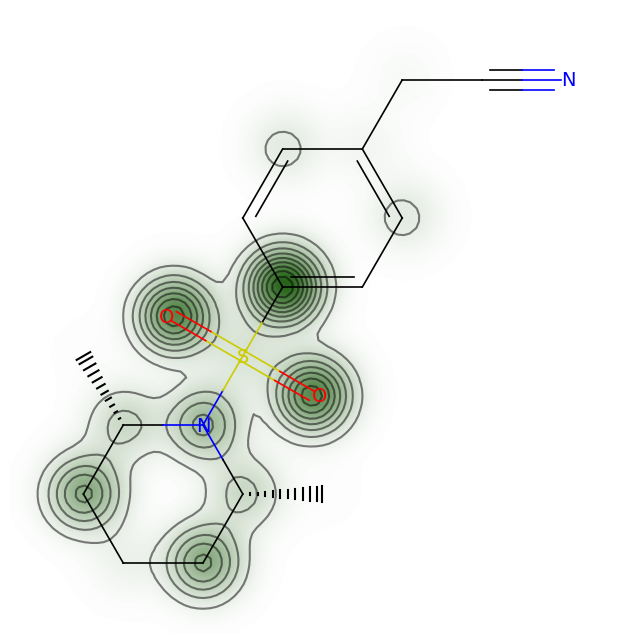

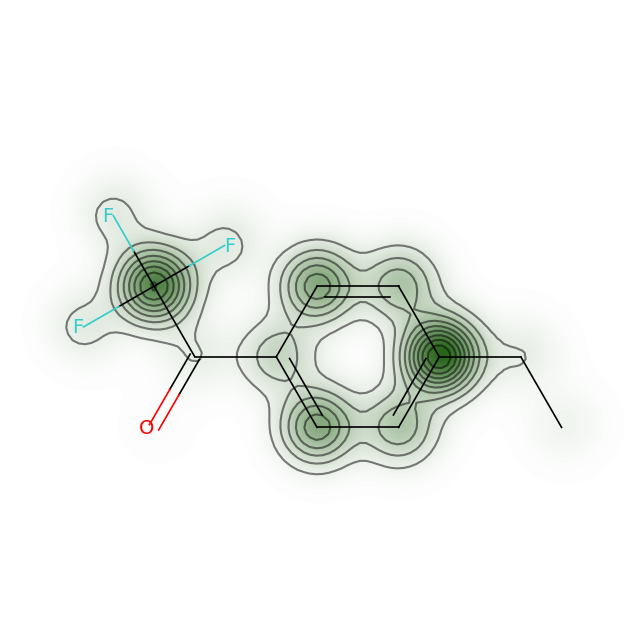

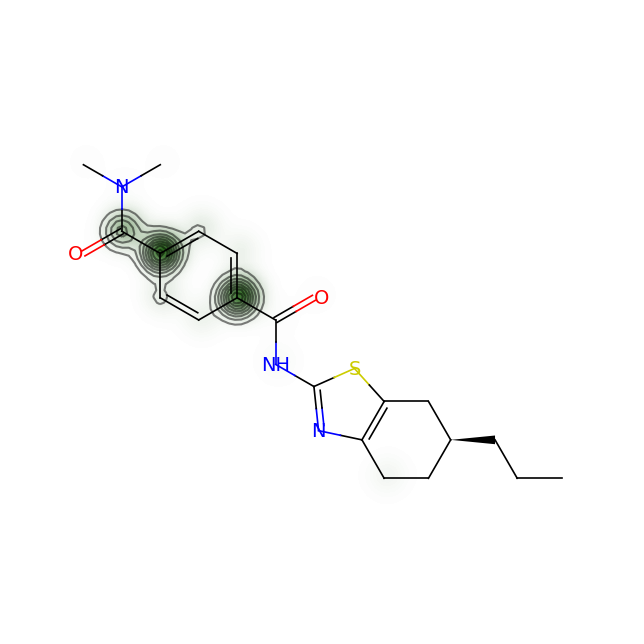

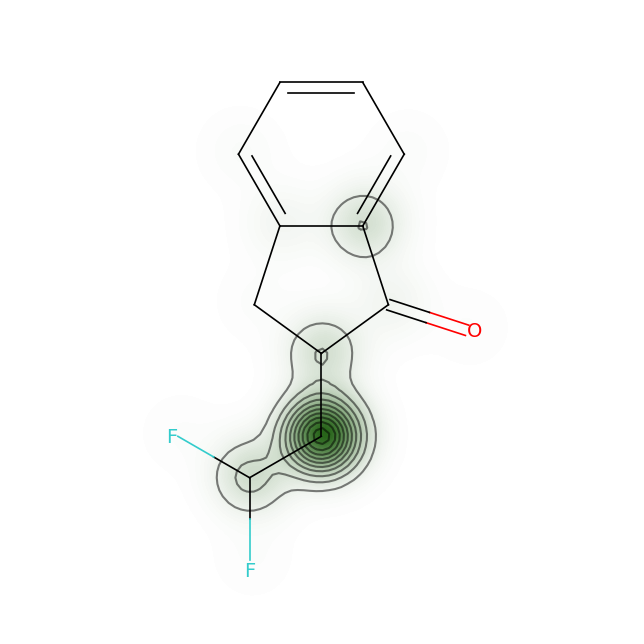

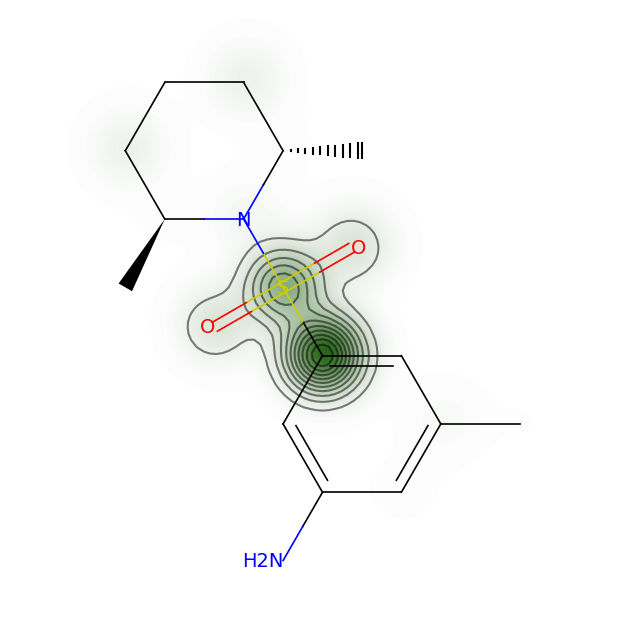

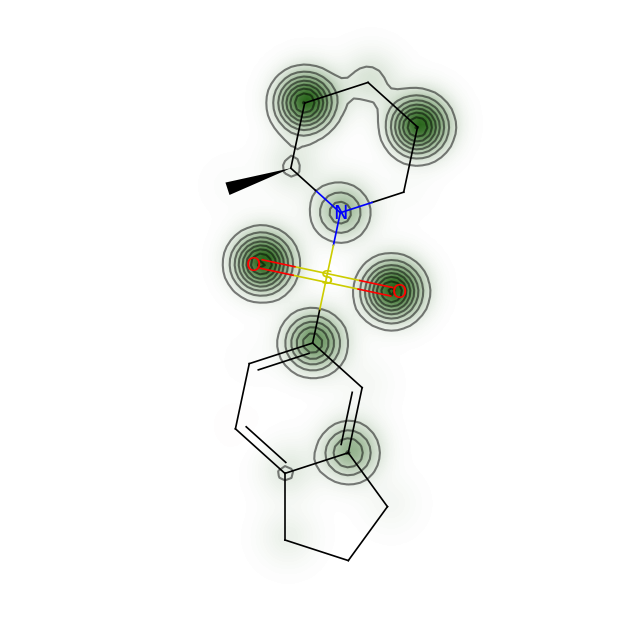

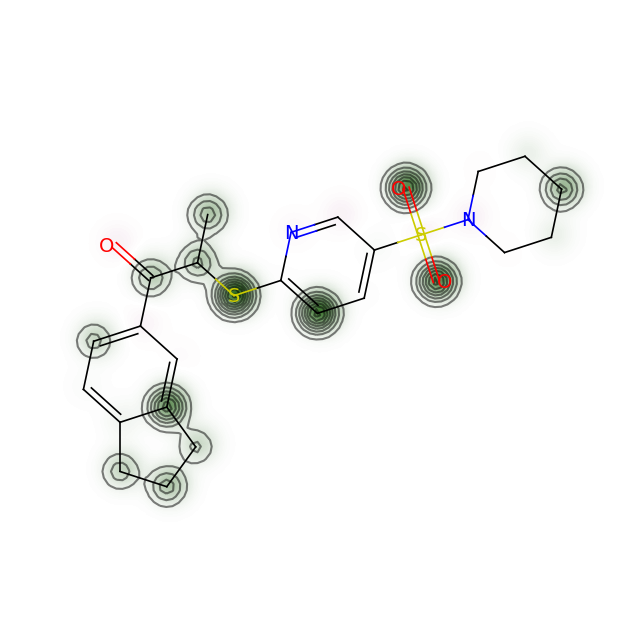

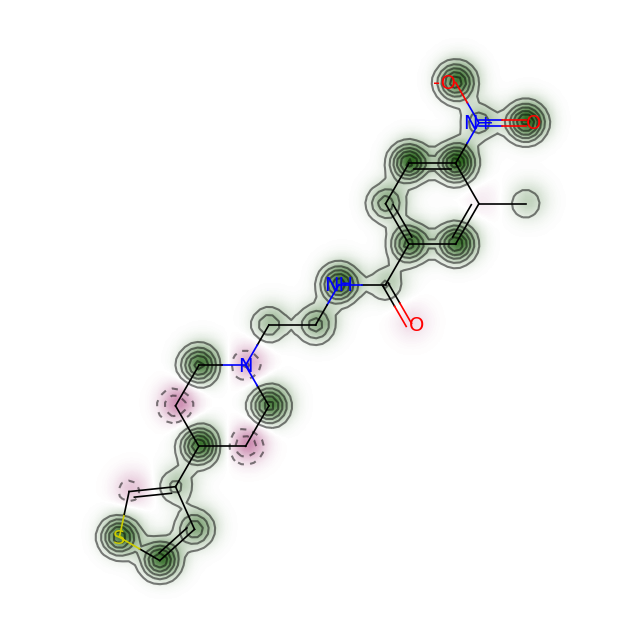

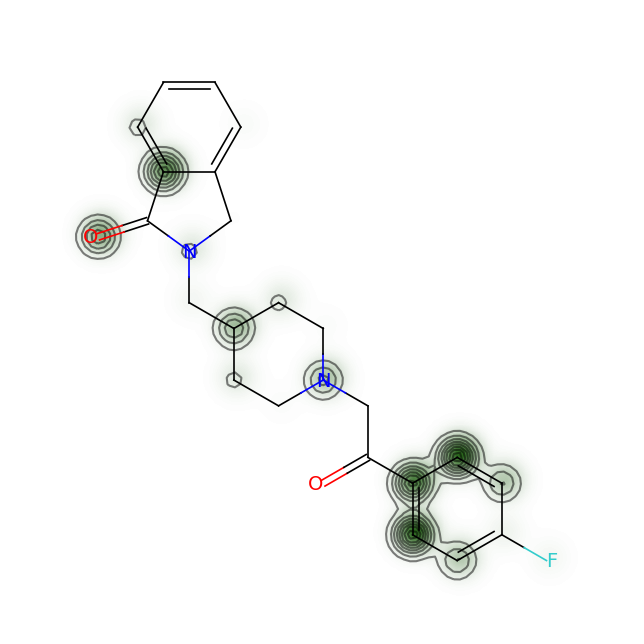

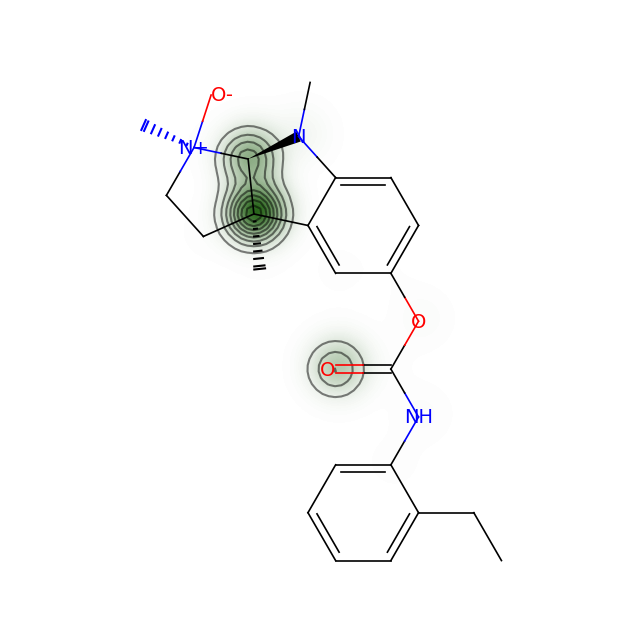

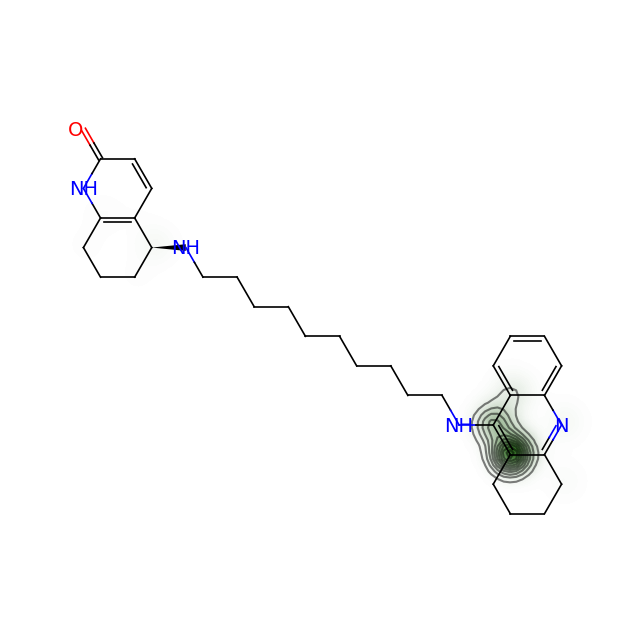

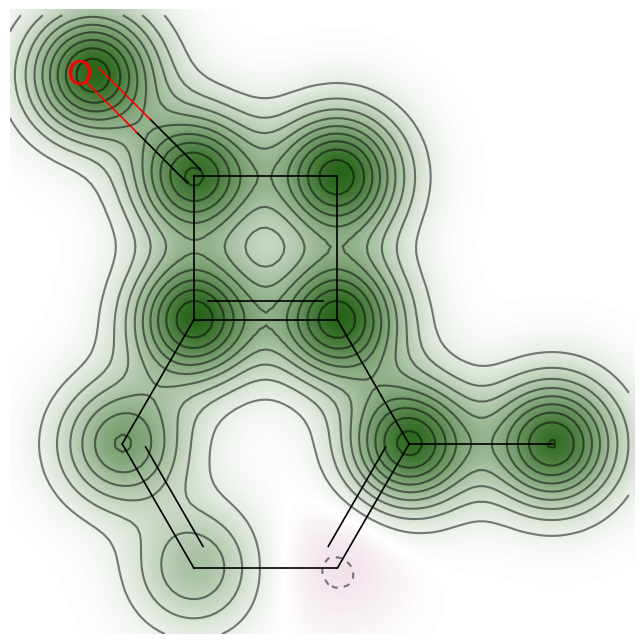

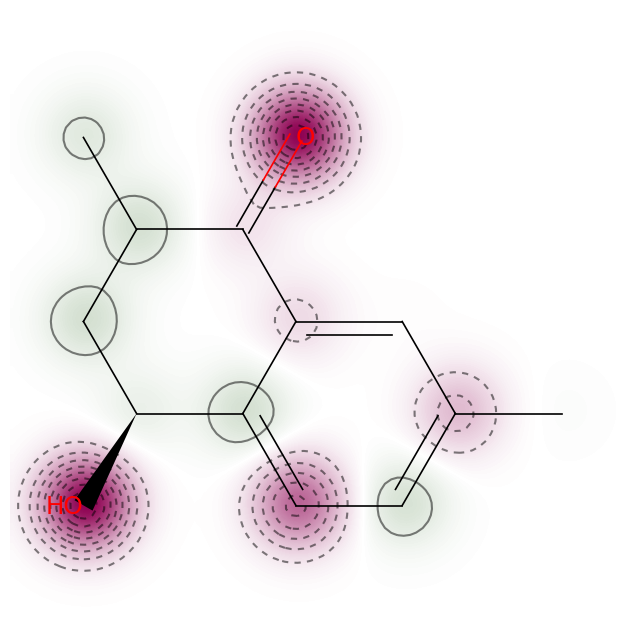

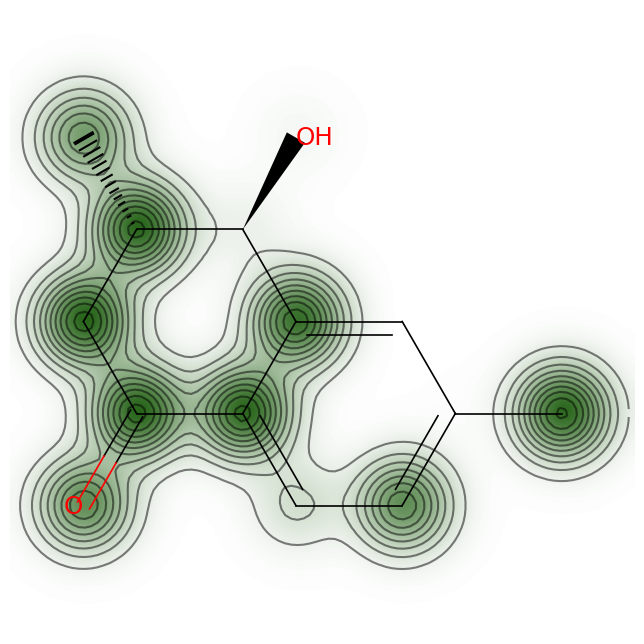

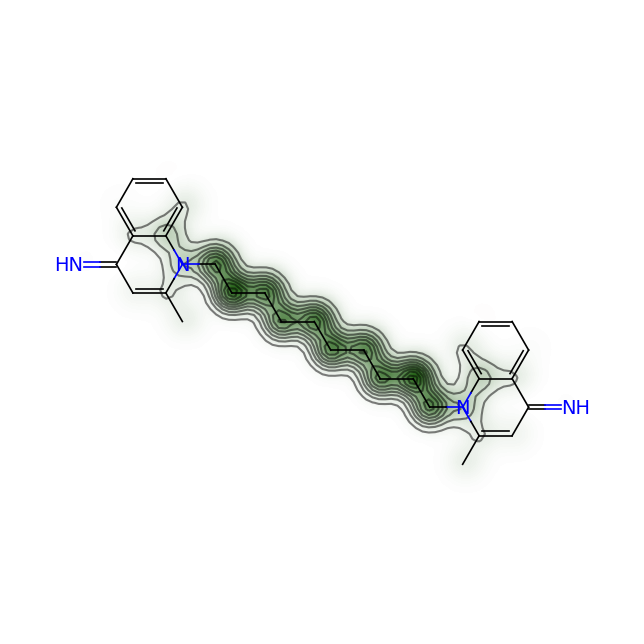

In [ ]:
import numpy as np
from rdkit import Chem
from rdkit.Chem import Draw, rdDepictor
from rdkit.Chem.Draw import rdMolDraw2D, SimilarityMaps
from matplotlib.colors import ListedColormap

draw2d = rdMolDraw2D.MolDraw2DSVG(400, 400)

def vis_contribs(mols, df, smi_or_sdf="sdf"):
    maps = []
    for mol in mols:
        wt = {}

        if smi_or_sdf == "smi":
            # safer: use .iloc for positions
            contribs = df.loc[mol.GetProp("_Name"), "Contrib"]
            for n, atom in enumerate(Chem.rdmolfiles.CanonicalRankAtoms(mol)):
                wt[atom] = contribs.iloc[n]

        elif smi_or_sdf == "sdf":
            smi = Chem.MolToSmiles(mol)

            # make sure the SMILES is found in df
            if smi not in df.index:
                print(f"Warning: {smi} not found in DataFrame index, skipping.")
                continue

            contribs = df.loc[smi, "Contrib"]
            for n, atom in enumerate(range(mol.GetNumHeavyAtoms())):
                wt[atom] = contribs.iloc[n]

        maps.append(SimilarityMaps.GetSimilarityMapFromWeights(mol, wt))

    return maps


# Example run
np.random.seed(42)
maps = vis_contribs(mols, df2, smi_or_sdf="sdf")


In [ ]:
print(df2.columns)
print(df2.head())

Index(['Fragment', 'Molecule', 'Contrib'], dtype='object')
                                                    Fragment  Molecule  \
CN(CCCCCCCCCCN(C)C(=O)Oc1cccc([N+](C)(C)C)c1)C(...  0.784982  0.657076   
CN(CCCCCCCCCCN(C)C(=O)Oc1cccc([N+](C)(C)C)c1)C(...  0.118464  0.657076   
CN(CCCCCCCCCCN(C)C(=O)Oc1cccc([N+](C)(C)C)c1)C(...  0.794529  0.657076   
CN(CCCCCCCCCCN(C)C(=O)Oc1cccc([N+](C)(C)C)c1)C(...  0.284772  0.657076   
CN(CCCCCCCCCCN(C)C(=O)Oc1cccc([N+](C)(C)C)c1)C(...  0.551902  0.657076   

                                                     Contrib  
CN(CCCCCCCCCCN(C)C(=O)Oc1cccc([N+](C)(C)C)c1)C(... -0.127906  
CN(CCCCCCCCCCN(C)C(=O)Oc1cccc([N+](C)(C)C)c1)C(...  0.538612  
CN(CCCCCCCCCCN(C)C(=O)Oc1cccc([N+](C)(C)C)c1)C(... -0.137453  
CN(CCCCCCCCCCN(C)C(=O)Oc1cccc([N+](C)(C)C)c1)C(...  0.372304  
CN(CCCCCCCCCCN(C)C(=O)Oc1cccc([N+](C)(C)C)c1)C(...  0.105174  


##References

* https://github.com/deepchem/deepchem/blob/master/examples/tutorials/Introduction_to_Graph_Convolutions.ipynb
* Ramsundar, B., Eastman, P., Walters, P., Pande, V., Leswing, K., & Wu, Z. (2019). Deep Learning for the Life Sciences. O’Reilly Media. https://www.amazon.com/Deep-Learning-Life-Sciences-Microscopy/dp/1492039837
* Vignaux, P. A., Lane, T. R., Urbina, F., Gerlach, J., Puhl, A. C., Snyder, S. H., & Ekins, S. (2023). Validation of Acetylcholinesterase Inhibition Machine Learning Models for Multiple Species. Chemical Research in Toxicology, 36(2), 188–201. https://doi.org/10.1021/acs.chemrestox.2c00283
* Duvenaud, D., Maclaurin, D., Aguilera-Iparraguirre, J., Gómez-Bombarelli, R., Hirzel, T., Aspuru-Guzik, A., & Adams, R. P. (2015). Convolutional Networks on Graphs for Learning Molecular Fingerprints (arXiv:1509.09292). arXiv. http://arxiv.org/abs/1509.09292
* Durant, J. L., Leland, B. A., Henry, D. R., & Nourse, J. G. (2002). Reoptimization of MDL Keys for Use in Drug Discovery. Journal of Chemical Information and Computer Sciences, 42(6), 1273–1280. https://doi.org/10.1021/ci010132r
*   https://github.com/deepchem/deepchem/blob/master/examples/tutorials/Atomic_Contributions_for_Molecules.ipynb


